### __Import__

In [1]:
import json
from data_model_loader import load_model, load_coco_2014_dataset, get_image_ids

model = load_model()
images = load_coco_2014_dataset()

# load file paths
with open('config.json', 'r') as file:
    config = json.load(file)
coco_folder = config['coco_folder']
annotation_file_path = config['annotation_file_path']

filename_to_image_id = get_image_ids()

OD model already present locally.
data/coco2014\val2014.zip already exists. Skipping download.
data/coco2014\val2014 already exists. Skipping extraction.
data/coco2014\annotations_trainval2014.zip already exists. Skipping download.
data/coco2014\annotations_trainval2014 already exists. Skipping extraction.
COCO 2014 dataset download and extraction complete.
Randomly selecting 1500 pictures ..
Done!


BS

Correct

# Plots

Final

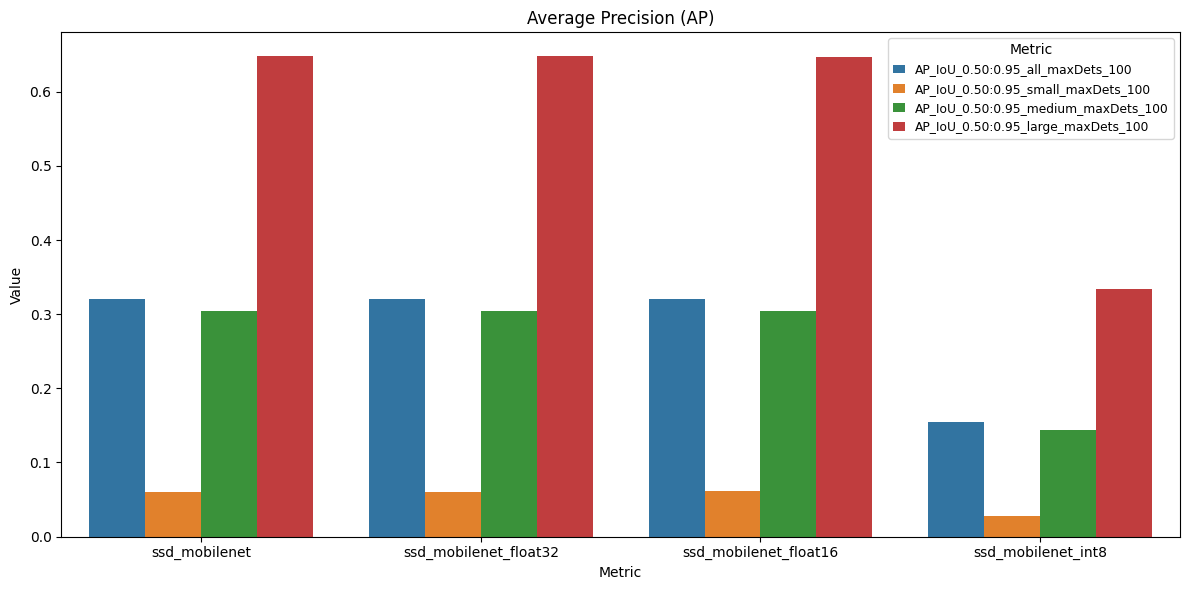

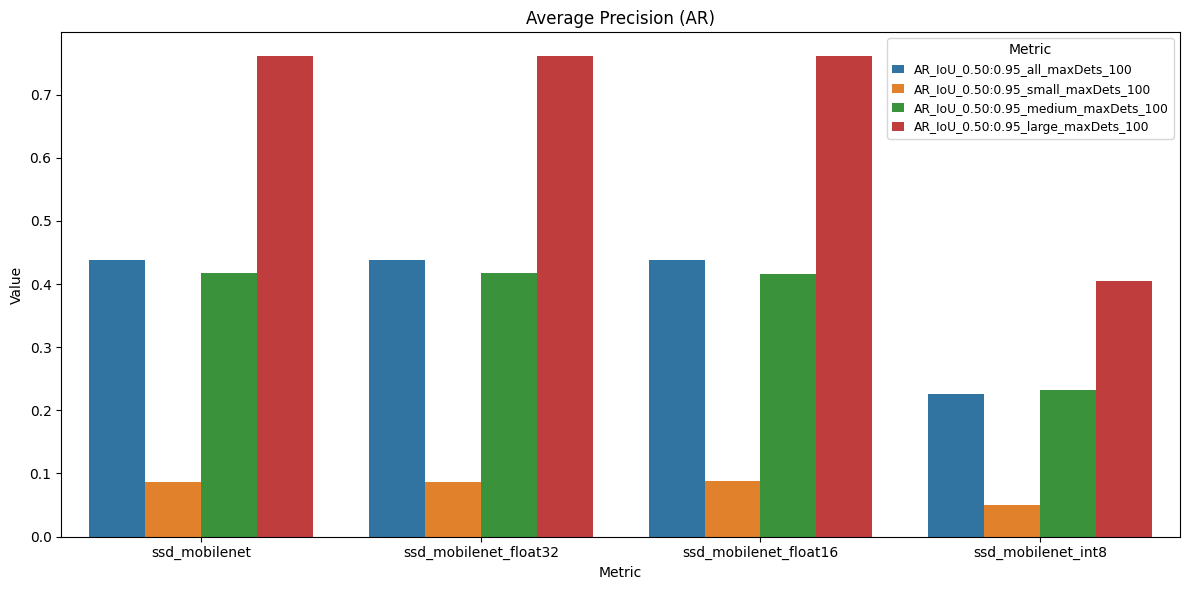

In [2]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def create_plots():
    with open('output/output.json', 'r') as f:
        data = json.load(f)

    ap_model_names = []
    ap_metric_names = []
    ap_values = []

    ar_model_names = []
    ar_metric_names = []
    ar_values = []

    metrics = [
        "AP_IoU_0.50:0.95_all_maxDets_100",
        "AP_IoU_0.50:0.95_small_maxDets_100",
        "AP_IoU_0.50:0.95_medium_maxDets_100",
        "AP_IoU_0.50:0.95_large_maxDets_100",
        "AR_IoU_0.50:0.95_all_maxDets_100",
        "AR_IoU_0.50:0.95_small_maxDets_100",
        "AR_IoU_0.50:0.95_medium_maxDets_100",
        "AR_IoU_0.50:0.95_large_maxDets_100"
    ]

    for model, model_data in data.items():
        for metric, value in model_data['metrics'].items():
            # Filter metrics starting with 'AP'
            if metric.startswith('AP') and metric in metrics:
                ap_model_names.append(model)
                ap_metric_names.append(metric)
                ap_values.append(value)
            elif metric.startswith('AR') and metric in metrics:
                ar_model_names.append(model)
                ar_metric_names.append(metric)
                ar_values.append(value)


    df_ap = pd.DataFrame({
        "Model" : ap_model_names,
        "Metric" : ap_metric_names,
        "Value" : ap_values
    })

    df_ar = pd.DataFrame({
        "Model" : ar_model_names,
        "Metric" : ar_metric_names,
        "Value" : ar_values
    })

    # AP
    plt.figure(figsize=(12, 6))
    sns.barplot(data=df_ap, x='Model', y='Value', hue='Metric')
    plt.xticks(rotation=0)
    plt.title('Average Precision (AP)')
    plt.xlabel('Metric')
    plt.ylabel('Value')
    plt.legend(title="Metric", loc="upper right", fontsize=8.8, handlelength=1)
    plt.tight_layout()
    plt.savefig('output/average_precision_plot.png', format='png', dpi=300)
    plt.show()

    # AR
    plt.figure(figsize=(12, 6))
    sns.barplot(data=df_ar, x='Model', y='Value', hue='Metric')
    plt.xticks(rotation=0)
    plt.title('Average Precision (AR)')
    plt.xlabel('Metric')
    plt.ylabel('Value')
    plt.legend(title="Metric", loc="upper right", fontsize=8.8, handlelength=1)
    plt.tight_layout()
    plt.savefig('output/average_recall_plot.png', format='png', dpi=300)
    plt.show()

create_plots()

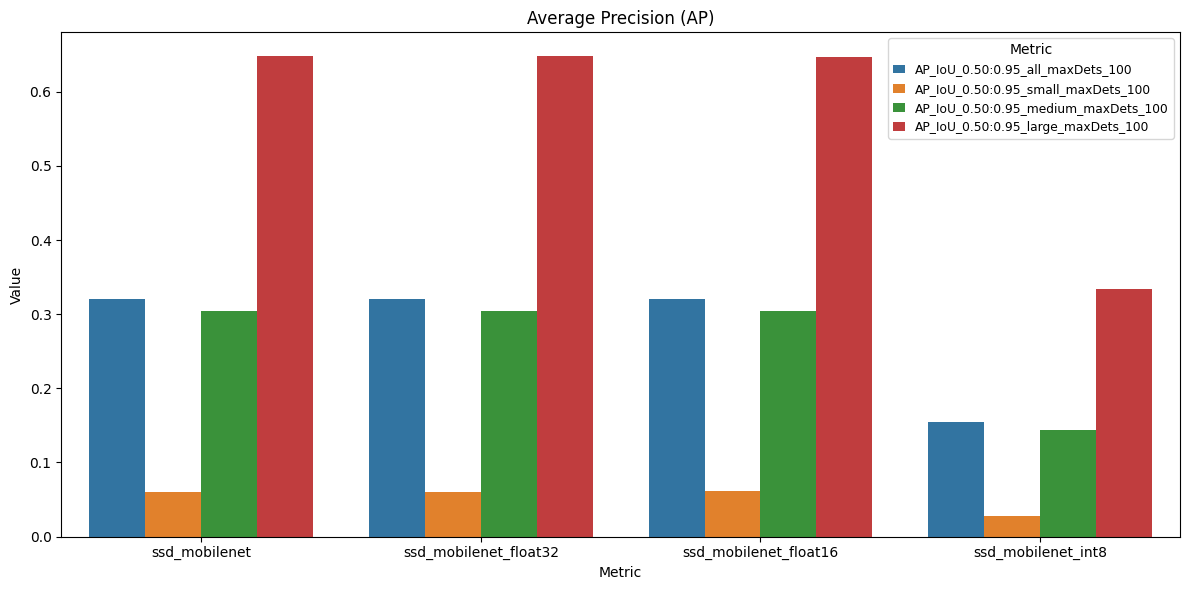

In [18]:
# Create the grouped barplot
plt.figure(figsize=(12, 6))
sns.barplot(data=df_ap, x='Model', y='Value', hue='Metric')
plt.xticks(rotation=0)
plt.title('Average Precision (AP)')
plt.xlabel('Metric')
plt.ylabel('Value')
plt.legend(title="Metric", loc="upper right", fontsize=8.8, handlelength=1)
plt.tight_layout()
plt.savefig('output/average_precision_plot.png', format='png', dpi=300)
plt.show()

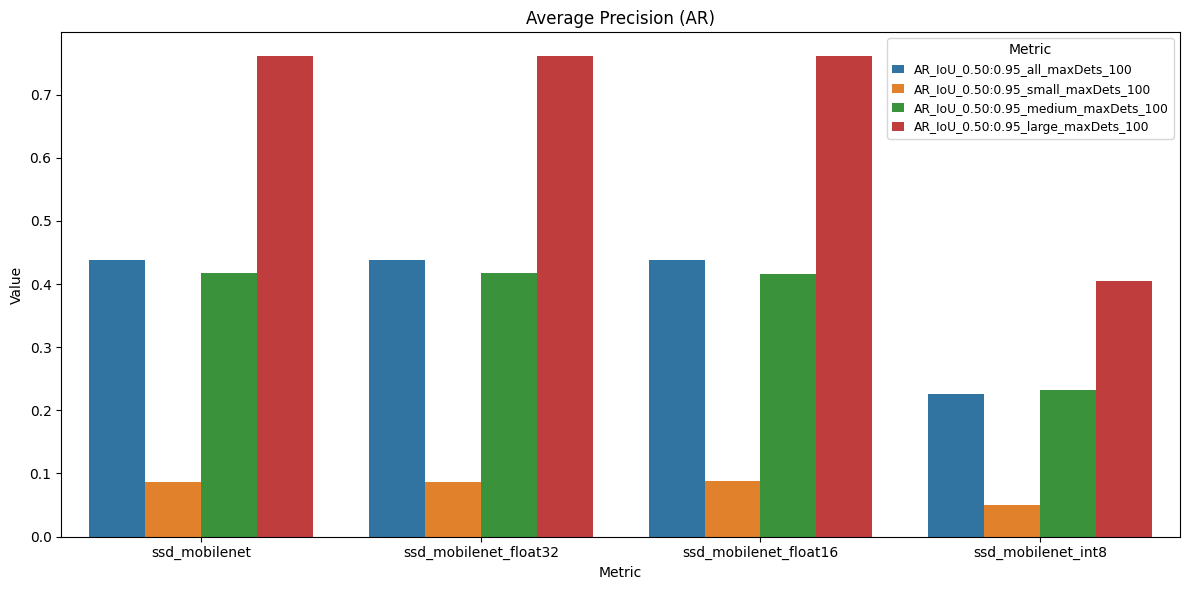

In [19]:
# Create the grouped barplot
plt.figure(figsize=(12, 6))
sns.barplot(data=df_ar, x='Model', y='Value', hue='Metric')
plt.xticks(rotation=0)
plt.title('Average Precision (AR)')
plt.xlabel('Metric')
plt.ylabel('Value')
plt.legend(title="Metric", loc="upper right", fontsize=8.8, handlelength=1)
plt.tight_layout()
plt.savefig('output/average_recall_plot.png', format='png', dpi=300)
plt.show()